In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [4]:
img=cv2.imread("mountain.jpg")
img.shape

(181, 278, 3)

#### BRG color

(np.float64(-0.5), np.float64(277.5), np.float64(180.5), np.float64(-0.5))

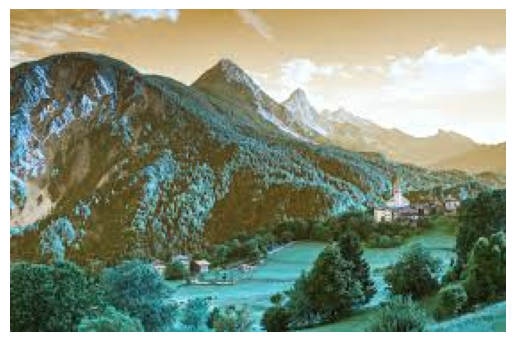

In [6]:
img=cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.axis('off')

#### RGB color

(np.float64(-0.5), np.float64(277.5), np.float64(180.5), np.float64(-0.5))

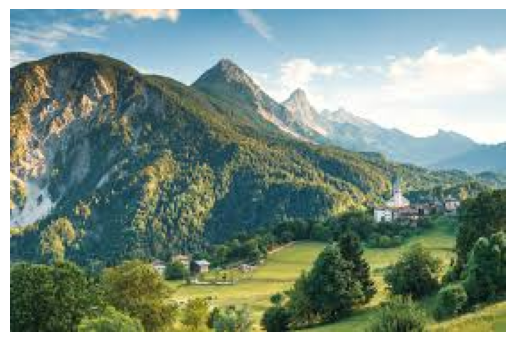

In [7]:
img=cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.axis('off')

#### Scaling

(np.float64(-0.5), np.float64(180.5), np.float64(277.5), np.float64(-0.5))

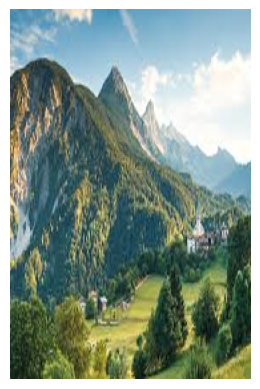

In [8]:
h,w=img.shape[:2]
scal = cv2.resize(img, dsize=(h, w), fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
plt.imshow(scal)
plt.axis('off')

(np.float64(-0.5), np.float64(177.5), np.float64(80.5), np.float64(-0.5))

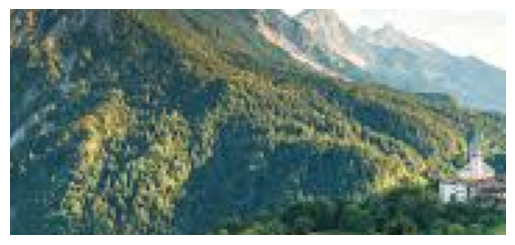

In [9]:
plt.imshow(img[50:-50, 50:-50, :]) # without opencv
plt.axis("off")

#### Translation

(np.float64(-0.5), np.float64(277.5), np.float64(180.5), np.float64(-0.5))

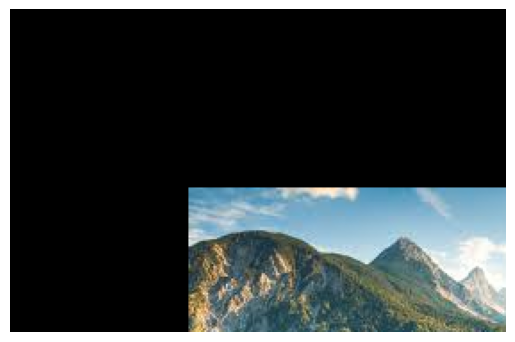

In [10]:
tx=100
ty=100
h,w=img.shape[:2]
m=np.float32([[1,0,tx],[0,1,ty]])
trans=cv2.warpAffine(img,m,(w,h))
plt.imshow(trans)
plt.axis('off')

(np.float64(-0.5), np.float64(277.5), np.float64(180.5), np.float64(-0.5))

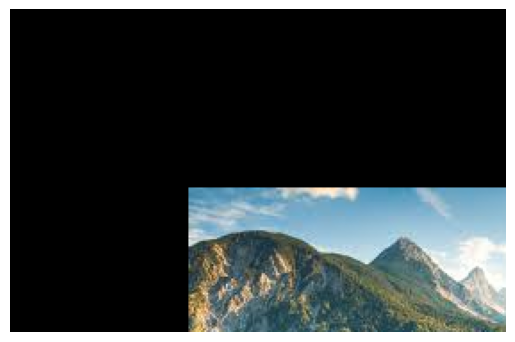

In [11]:
tx, ty = 100, 100
h, w = img.shape[:2]

trans = np.zeros_like(img)

y, x = np.indices((h, w))
src_x = x - tx
src_y = y - ty

mask = (src_x >= 0) & (src_x < w) & (src_y >= 0) & (src_y < h)

trans[y[mask], x[mask]] = img[src_y[mask], src_x[mask]]

plt.imshow(trans)
plt.axis('off')


#### Rotation

(np.float64(-0.5), np.float64(277.5), np.float64(180.5), np.float64(-0.5))

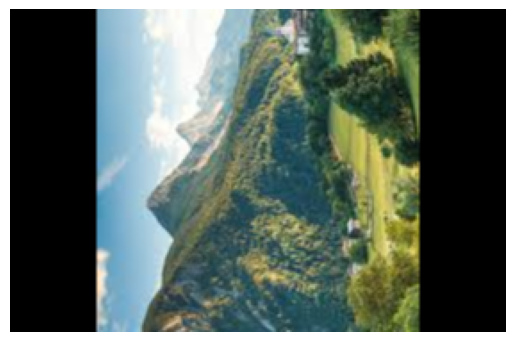

In [12]:
h,w=img.shape[:2]
m= cv2.getRotationMatrix2D(((w-1)/2.0,(h-1)/2.0),90,1)
rot = cv2.warpAffine(img,m,(w,h))
plt.imshow(rot)
plt.axis('off')

####  Affine Transformation

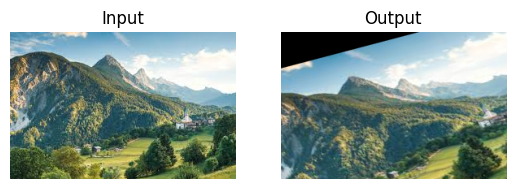

In [13]:
h,w=img.shape[:2]

pts1 = np.float32([[50,50],[200,50],[50,200]])
pts2 = np.float32([[10,100],[200,50],[100,250]])
 
M = cv2.getAffineTransform(pts1,pts2)
 
at = cv2.warpAffine(img,M,(w,h))
 
plt.subplot(121),plt.imshow(img),plt.title('Input')
plt.axis('off')

plt.subplot(122),plt.imshow(at),plt.title('Output')
plt.axis('off')
plt.show()

#### Perspective Transformation

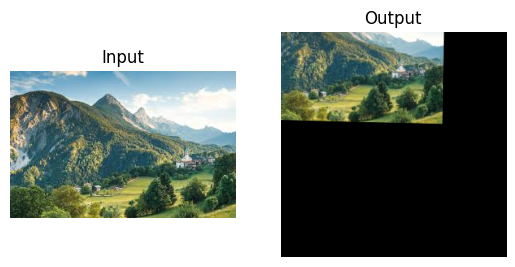

In [14]:
h,w=img.shape[:2]

pts1 = np.float32([[56,65],[368,52],[28,387],[389,390]])
pts2 = np.float32([[0,0],[300,0],[0,300],[300,300]])
 
M = cv2.getPerspectiveTransform(pts1,pts2)
 
pt = cv2.warpPerspective(img,M,(300,300))
 
plt.subplot(121),plt.imshow(img),plt.title('Input')
plt.axis("off")

plt.subplot(122),plt.imshow(pt),plt.title('Output')
plt.axis("off")

plt.show()
